# Training: BioLeakyRNN on CuedTarget V3

Stage 0 → 1 → 2 curriculum.  V3 obs: (7,) with continuous spatial coords.

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import matplotlib.pyplot as plt
from pathlib import Path

from src import BioLeakyRNN, CuedTargetWithDistractorsV3, TrainConfig, train_supervised

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)
Path('../checkpoints').mkdir(exist_ok=True)

device: cpu


In [2]:
def make_model():
    return BioLeakyRNN(
        input_size=7, hidden_size=128, output_size=2,
        dt=20.0, tau=100.0, activation='softplus', sigma_rec=0.05,
        rec_init='diag', use_ei=True, exc_ratio=0.7, use_dale=True,
        mask_seed=42,
    ).to(device)

## Stage 0 — detect target, no cue, no distractors

In [ ]:
def make_env_stage0():
    return CuedTargetWithDistractorsV3(dt=20, cue_strength=0.0,
                                       p_distractor_trial=0.0, distractor_strength=0.0)

model = make_model()
cfg0 = TrainConfig(
    batch_size=64, lr=1e-3, max_updates=1000,
    print_every=50, device=device,
    stop_on_no_miss=0,  # на stage 0 miss норма, не останавливаем
)
history0 = train_supervised(model, make_env_stage0, cfg0)
torch.save({'state_dict': model.state_dict()}, '../checkpoints/stage0.pt')

## Stage 1 — add cue

In [ ]:
def make_env_stage1():
    return CuedTargetWithDistractorsV3(dt=20, cue_strength=1.0,
                                       p_distractor_trial=0.0, distractor_strength=0.0)

model = make_model()
model.load_state_dict(torch.load('../checkpoints/stage0.pt', weights_only=True)['state_dict'])
cfg1 = TrainConfig(
    batch_size=64, lr=1e-3, max_updates=1000,
    print_every=50, device=device,
    stop_on_no_miss=0,  # на stage 1 тоже
)
history1 = train_supervised(model, make_env_stage1, cfg1)
torch.save({'state_dict': model.state_dict()}, '../checkpoints/stage1.pt')

## Stage 2 — cue + distractors

In [ ]:
def make_env_stage2():
    return CuedTargetWithDistractorsV3(dt=20, cue_strength=1.0,
                                       p_distractor_trial=0.6, distractor_strength=1.0)

model = make_model()
model.load_state_dict(torch.load('../checkpoints/stage1.pt', weights_only=True)['state_dict'])
cfg2 = TrainConfig(
    batch_size=64, lr=1e-3, max_updates=8700,
    print_every=50, device=device,
)  # early stopping включён (дефолт stop_on_no_miss=3)
history2 = train_supervised(model, make_env_stage2, cfg2)
torch.save({'state_dict': model.state_dict()}, '../checkpoints/stage2.pt')

## Training curves

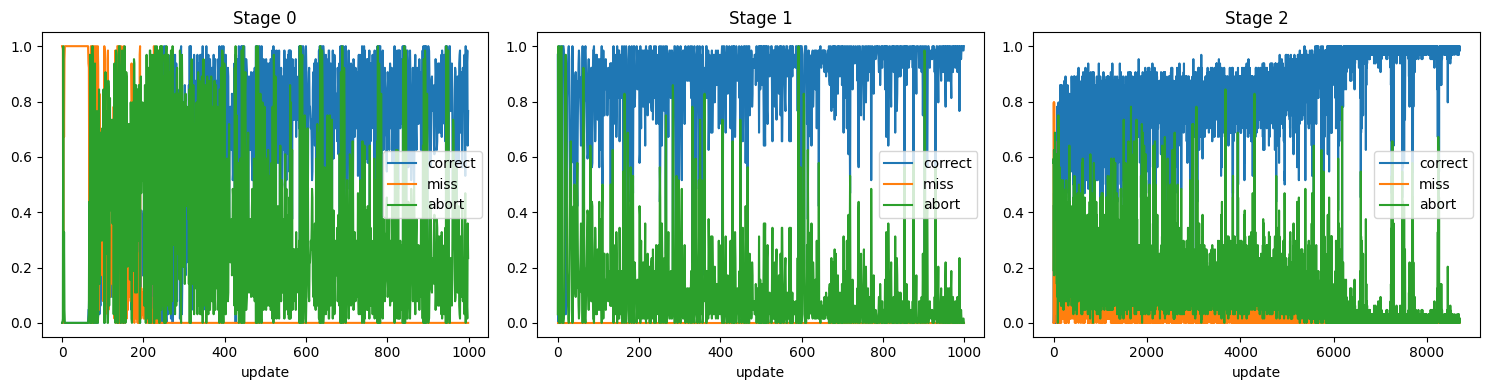

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, hist, stage in zip(axes, [history0, history1, history2], [0, 1, 2]):
    ax.plot(hist['p_correct'], label='correct')
    ax.plot(hist['p_miss'],    label='miss')
    ax.plot(hist['p_abort'],   label='abort')
    ax.set_title(f'Stage {stage}')
    ax.set_xlabel('update'); ax.legend()
plt.tight_layout(); plt.show()